In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import gc, json, pickle, random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import scipy.io
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score,
    precision_score, cohen_kappa_score, roc_auc_score,
)

DATA_ROOT = Path("/kaggle/input/datasets/daprosero/mi-tdah-dataset/MI_TDAH_Dataset/TDAH")
FOLDS_PATH = DATA_ROOT / "folds.pkl"
ADHD_DIR = DATA_ROOT / "ieee/ADHD_group"
CONTROL_DIR = DATA_ROOT / "ieee/Control_group"
MODEL_ROOT = Path(
    "/kaggle/input/datasets/alejandragomezr/models-cte-net/"
    "resultados_eegnet_tdah_ARTICULO-20260715T223815Z-1-001/"
    "resultados_eegnet_tdah_ARTICULO"
)
OUTPUT_ROOT = Path("/kaggle/working/EEGNet_reinference_complete")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def clean_id(x):
    if isinstance(x, bytes):
        x = x.decode()
    x = Path(str(x)).name
    return x[:-4] if x.lower().endswith(".mat") else x


def process_adhd_subjects():
    with open(FOLDS_PATH, "rb") as f:
        raw_folds = pickle.load(f)

    folds = []
    for train, val, test in raw_folds:
        folds.append((
            [clean_id(x) for x in train],
            [clean_id(x) for x in val],
            [clean_id(x) for x in test],
        ))

    protocol = set()
    test_counter = Counter()
    for fold, (train, val, test) in enumerate(folds):
        tr, va, te = set(train), set(val), set(test)
        assert not (tr & va or tr & te or va & te), f"Solapamiento en fold {fold}"
        protocol.update(tr | va | te)
        test_counter.update(test)

    assert len(folds) == 5
    assert len(protocol) == 120
    assert all(v == 1 for v in test_counter.values())

    adhd_files = {p.stem: p for p in sorted(ADHD_DIR.glob("*.mat"))}
    control_files = {p.stem: p for p in sorted(CONTROL_DIR.glob("*.mat"))}
    missing = protocol - (set(adhd_files) | set(control_files))
    assert not missing, f"Faltan sujetos: {missing}"

    controls = sorted(protocol & set(control_files))
    adhd = sorted(protocol & set(adhd_files))
    unused = sorted((set(adhd_files) | set(control_files)) - protocol)
    assert len(controls) == 60 and len(adhd) == 60

    records = (
        [(s, 0, "Control", control_files[s]) for s in controls] +
        [(s, 1, "ADHD", adhd_files[s]) for s in adhd]
    )

    X, y, sbjs, window_ids, rows = [], [], [], [], []
    global_idx = 0

    for sid, label, class_name, path in records:
        mat = scipy.io.loadmat(path)
        if sid in mat:
            raw = np.asarray(mat[sid])
            variable = sid
        else:
            candidates = [(k, np.asarray(v)) for k, v in mat.items()
                          if not k.startswith("__") and np.asarray(v).ndim == 2
                          and 19 in np.asarray(v).shape]
            variable, raw = max(candidates, key=lambda z: z[1].size)

        eeg = raw.astype(np.float32).T
        if eeg.shape[0] != 19 and raw.shape[0] == 19:
            eeg = raw.astype(np.float32)
        assert eeg.shape[0] == 19, f"Forma incorrecta {sid}: {eeg.shape}"

        local_id = 0
        for start in range(0, eeg.shape[1] - 512 + 1, 256):
            end = start + 512
            X.append(eeg[:, start:end])
            y.append(label)
            sbjs.append(sid)
            window_ids.append(local_id)
            rows.append({
                "global_window_index": global_idx,
                "subject_id": sid,
                "label": label,
                "class_name": class_name,
                "window_id": local_id,
                "window_name": f"Window {local_id + 1}",
                "start_sample": start,
                "end_sample": end,
                "mat_variable": variable,
                "mat_filename": path.name,
            })
            local_id += 1
            global_idx += 1

    X = np.stack(X).astype(np.float32)
    y = np.asarray(y, dtype=np.int64)
    sbjs = np.asarray(sbjs, dtype=str)
    window_ids = np.asarray(window_ids, dtype=np.int64)

    print("X:", X.shape, X.dtype)
    print("y:", y.shape, y.dtype)
    print("Sujetos:", len(np.unique(sbjs)))
    print("No utilizado:", unused)

    return {
        "X": X,
        "y_int": y,
        "y_onehot": np.eye(2, dtype=np.float32)[y],
        "subject_ids": sbjs,
        "window_ids": window_ids,
        "metadata": pd.DataFrame(rows),
        "folds": folds,
    }


class Conv2dSame(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, bias=False, groups=1):
        super().__init__()
        kh, kw = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        ph, pw = kh - 1, kw - 1
        self.pad = nn.ZeroPad2d((pw // 2, pw - pw // 2, ph // 2, ph - ph // 2))
        self.conv = nn.Conv2d(in_channels, out_channels, (kh, kw),
                              padding=0, bias=bias, groups=groups)

    def forward(self, x):
        return self.conv(self.pad(x))


class EEGNetTorch(nn.Module):
    def __init__(self, nb_classes=2, Chans=19, Samples=512, dropoutRate=0.5,
                 kernLength=64, F1=8, D=2, F2=None, norm_rate=0.25,
                 dropoutType="Dropout", bn_eps=1e-3, bn_momentum=0.01,
                 return_logits=False):
        super().__init__()
        F2 = F1 * D if F2 is None else F2
        self.return_logits = return_logits
        Drop = nn.Dropout2d if dropoutType == "SpatialDropout2D" else nn.Dropout

        self.conv_temporal = Conv2dSame(1, F1, (1, kernLength), bias=False)
        self.bn1 = nn.BatchNorm2d(F1, eps=bn_eps, momentum=bn_momentum)
        self.depthwise_spatial = nn.Conv2d(F1, F1 * D, (Chans, 1),
                                           groups=F1, bias=False)
        self.bn2 = nn.BatchNorm2d(F1 * D, eps=bn_eps, momentum=bn_momentum)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.dropout1 = Drop(dropoutRate)
        self.separable_depthwise = Conv2dSame(F1 * D, F1 * D, (1, 16),
                                               bias=False, groups=F1 * D)
        self.separable_pointwise = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2, eps=bn_eps, momentum=bn_momentum)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.dropout2 = Drop(dropoutRate)
        self.classifier = nn.Linear(F2 * (Samples // 32), nb_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.bn1(self.conv_temporal(x))
        x = F.elu(self.bn2(self.depthwise_spatial(x)))
        x = self.dropout1(self.pool1(x))
        x = self.separable_pointwise(self.separable_depthwise(x))
        x = F.elu(self.bn3(x))
        x = self.dropout2(self.pool2(x))
        logits = self.classifier(torch.flatten(x, 1))
        probs = torch.softmax(logits, dim=1)
        out = {"out_activation": probs}
        if self.return_logits:
            out["logits"] = logits
        return out


def load_state(path):
    try:
        obj = torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(path, map_location="cpu")
    if "model_state_dict" in obj:
        obj = obj["model_state_dict"]
    elif "state_dict" in obj:
        obj = obj["state_dict"]
    clean = {}
    for k, v in obj.items():
        k = k.removeprefix("module.").removeprefix("_orig_mod.")
        clean[k] = v
    return clean


def get_test(data, fold):
    test_subjects = data["folds"][fold][2]
    mask = np.isin(data["subject_ids"], test_subjects)
    return {
        "X": data["X"][mask],
        "y": data["y_int"][mask],
        "sbjs": data["subject_ids"][mask],
        "window_ids": data["window_ids"][mask],
        "metadata": data["metadata"].loc[mask].reset_index(drop=True),
    }


def infer(model, X):
    loader = DataLoader(TensorDataset(torch.from_numpy(X)), batch_size=BATCH_SIZE,
                        shuffle=False, drop_last=False)
    probs = []
    model.eval()
    with torch.inference_mode():
        for (xb,) in loader:
            probs.append(model(xb.to(DEVICE))["out_activation"].cpu().numpy())
    probs = np.concatenate(probs).astype(np.float32)
    return probs, probs[:, 1], np.argmax(probs, axis=1)


def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, average="binary", zero_division=0),
        "precision": precision_score(y_true, y_pred, average="binary", zero_division=0),
        "kappa": cohen_kappa_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
    }


def run_all(data):
    windows_all, subjects_all, metrics_all, comparisons = [], [], [], []

    for seed in range(10):
        for fold in range(5):
            fold_dir = MODEL_ROOT / f"EEGNet_TDAH_fixed_seed_{seed}" / f"fold_{fold}"
            with open(fold_dir / "fold_result.pkl", "rb") as f:
                saved = pickle.load(f)

            set_seed(seed + fold)
            model = EEGNetTorch(**saved["model_args"]).to(DEVICE)
            model.load_state_dict(load_state(fold_dir / "best_state.pt"), strict=True)

            test = get_test(data, fold)
            assert len(np.unique(test["sbjs"])) == 24
            probs, y_prob, y_pred = infer(model, test["X"])
            current = calculate_metrics(test["y"], y_pred, y_prob)

            print(f"seed={seed} fold={fold} | "
                  f"guardado={saved['fold_metrics']['accuracy']:.10f} | "
                  f"recalculado={current['accuracy']:.10f}")

            comp = {"seed": seed, "fold": fold}
            matches = []
            for metric in ["accuracy", "balanced_accuracy", "recall", "precision", "kappa", "auc"]:
                old, new = float(saved["fold_metrics"][metric]), float(current[metric])
                ok = np.isclose(old, new, atol=1e-6, rtol=0)
                comp[f"saved_{metric}"] = old
                comp[f"recomputed_{metric}"] = new
                comp[f"difference_{metric}"] = new - old
                comp[f"match_{metric}"] = bool(ok)
                matches.append(ok)
            comp["all_metrics_match"] = bool(all(matches))
            comparisons.append(comp)

            meta = test["metadata"]
            dfw = pd.DataFrame({
                "model": "EEGNet", "seed": seed, "fold": fold,
                "global_window_index": meta["global_window_index"],
                "subject_id": test["sbjs"], "label": test["y"],
                "class_name": np.where(test["y"] == 1, "ADHD", "Control"),
                "window_id": test["window_ids"], "window_name": meta["window_name"],
                "start_sample": meta["start_sample"], "end_sample": meta["end_sample"],
                "y_true": test["y"], "prob_control": probs[:, 0],
                "prob_adhd": probs[:, 1], "y_pred": y_pred,
                "correct": (y_pred == test["y"]).astype(int),
            })
            windows_all.append(dfw)

            dfs = dfw.groupby(
                ["model", "seed", "fold", "subject_id", "label", "class_name"],
                as_index=False
            ).agg(
                n_windows=("correct", "size"),
                n_correct_windows=("correct", "sum"),
                window_accuracy=("correct", "mean"),
                mean_prob_adhd=("prob_adhd", "mean"),
                std_prob_adhd=("prob_adhd", "std"),
            )
            subjects_all.append(dfs)
            metrics_all.append({
                "model": "EEGNet", "seed": seed, "fold": fold,
                "n_test_windows": len(test["y"]), "n_test_subjects": 24, **current
            })

            del model, test, probs, y_prob, y_pred
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    windows = pd.concat(windows_all, ignore_index=True)
    subjects_seed = pd.concat(subjects_all, ignore_index=True)
    fold_metrics = pd.DataFrame(metrics_all)
    comparison = pd.DataFrame(comparisons)

    subjects_final = subjects_seed.groupby(
        ["model", "subject_id", "label", "class_name"], as_index=False
    ).agg(
        fold=("fold", "first"), n_seeds=("seed", "nunique"),
        n_windows_per_seed=("n_windows", "first"),
        mean_window_accuracy=("window_accuracy", "mean"),
        std_window_accuracy=("window_accuracy", "std"),
        median_window_accuracy=("window_accuracy", "median"),
        min_window_accuracy=("window_accuracy", "min"),
        max_window_accuracy=("window_accuracy", "max"),
        mean_prob_adhd=("mean_prob_adhd", "mean"),
    )
    subjects_final["mean_window_accuracy_percent"] = 100 * subjects_final["mean_window_accuracy"]
    subjects_final["std_window_accuracy_percent"] = 100 * subjects_final["std_window_accuracy"]

    summary = []
    for metric in ["accuracy", "balanced_accuracy", "recall", "precision", "kappa", "auc"]:
        v = fold_metrics[metric].to_numpy(float)
        summary.append({"metric": metric, "mean": np.mean(v),
                        "std_sample": np.std(v, ddof=1), "n": len(v)})
    summary = pd.DataFrame(summary)

    assert len(fold_metrics) == 50
    assert len(subjects_seed) == 1200
    assert len(subjects_final) == 120

    windows.to_csv(OUTPUT_ROOT / "EEGNet_all_window_predictions.csv", index=False)
    subjects_seed.to_csv(OUTPUT_ROOT / "EEGNet_subject_summary_by_seed.csv", index=False)
    subjects_final.to_csv(OUTPUT_ROOT / "EEGNet_subject_accuracy_across_seeds.csv", index=False)
    fold_metrics.to_csv(OUTPUT_ROOT / "EEGNet_fold_metrics_recomputed.csv", index=False)
    comparison.to_csv(OUTPUT_ROOT / "EEGNet_saved_vs_recomputed_metrics.csv", index=False)
    summary.to_csv(OUTPUT_ROOT / "EEGNet_summary_50_runs.csv", index=False)

    with open(OUTPUT_ROOT / "EEGNet_reinference_summary.json", "w") as f:
        json.dump({"all_metrics_match": bool(comparison["all_metrics_match"].all()),
                   "summary": summary.to_dict("records")}, f, indent=2)

    print("\nTodos coinciden:", comparison["all_metrics_match"].all())
    print(summary.to_string(index=False))
    print("Archivos guardados en:", OUTPUT_ROOT)
    return windows, subjects_seed, subjects_final, fold_metrics, comparison, summary


print("Device:", DEVICE)
data = process_adhd_subjects()
(
    df_window_predictions,
    df_subject_by_seed,
    df_subject_accuracy,
    df_fold_metrics,
    df_comparison,
    df_summary_50_runs,
) = run_all(data)

print(df_subject_accuracy.head())


Device: cuda
X: (8213, 19, 512) float32
y: (8213,) int64
Sujetos: 120
No utilizado: ['v36p']
seed=0 fold=0 | guardado=0.7996389892 | recalculado=0.7996389892
seed=0 fold=1 | guardado=0.7791293214 | recalculado=0.7791293214
seed=0 fold=2 | guardado=0.7329716697 | recalculado=0.7329716697
seed=0 fold=3 | guardado=0.7953980100 | recalculado=0.7953980100
seed=0 fold=4 | guardado=0.8269454123 | recalculado=0.8269454123
seed=1 fold=0 | guardado=0.8754512635 | recalculado=0.8754512635
seed=1 fold=1 | guardado=0.8982074264 | recalculado=0.8982074264
seed=1 fold=2 | guardado=0.7823990356 | recalculado=0.7823990356
seed=1 fold=3 | guardado=0.8725124378 | recalculado=0.8725124378
seed=1 fold=4 | guardado=0.8333333333 | recalculado=0.8333333333
seed=2 fold=0 | guardado=0.8200962696 | recalculado=0.8200962696
seed=2 fold=1 | guardado=0.7938540333 | recalculado=0.7938540333
seed=2 fold=2 | guardado=0.8408679928 | recalculado=0.8408679928
seed=2 fold=3 | guardado=0.8687810945 | recalculado=0.86878109

Sujetos por clase:
label  class_name
0      Control       60
1      ADHD          60
Name: subject_id, dtype: int64

Orden de sujetos guardado en:
/kaggle/working/EEGNet_reinference_complete/figures/EEGNet_heatmap_subject_order.csv


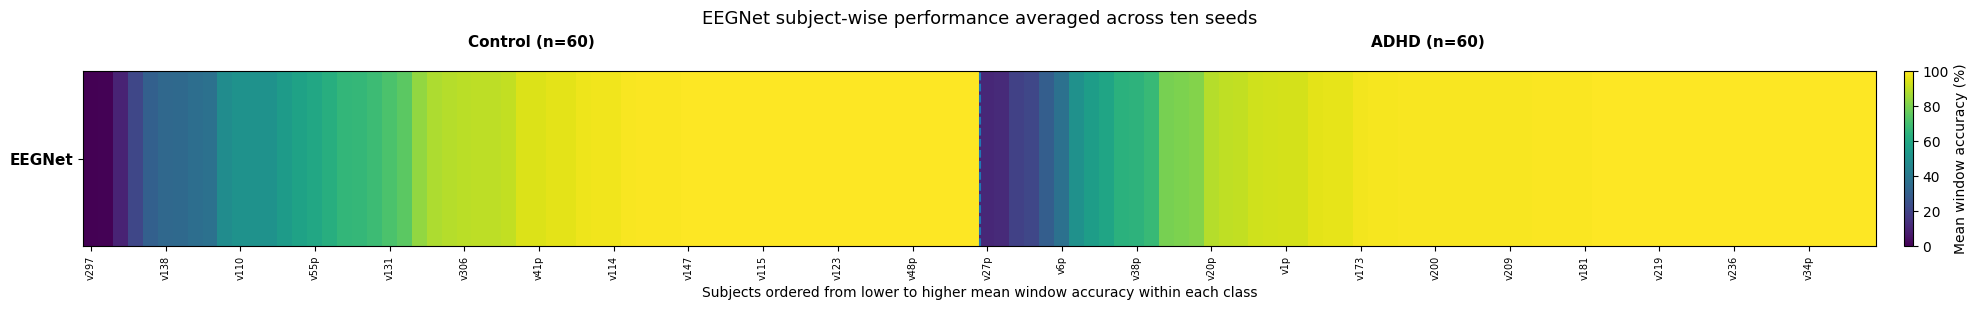


Heatmap promedio guardado en:
/kaggle/working/EEGNet_reinference_complete/figures/EEGNet_heatmap_mean_by_subject.png
/kaggle/working/EEGNet_reinference_complete/figures/EEGNet_heatmap_mean_by_subject.pdf


In [2]:
# ============================================================
# HEATMAPS POR SUJETO — EEGNet
# 1) Promedio de las 10 seeds
# 2) Accuracy individual para cada seed
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. RUTAS
# ============================================================

RESULTS_DIR = Path(
    "/kaggle/working/EEGNet_reinference_complete"
)

MEAN_CSV = RESULTS_DIR / "EEGNet_subject_accuracy_across_seeds.csv"
SEED_CSV = RESULTS_DIR / "EEGNet_subject_summary_by_seed.csv"

FIGURE_DIR = RESULTS_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MEAN_PNG = FIGURE_DIR / "EEGNet_heatmap_mean_by_subject.png"
MEAN_PDF = FIGURE_DIR / "EEGNet_heatmap_mean_by_subject.pdf"

SEEDS_PNG = FIGURE_DIR / "EEGNet_heatmap_seeds_by_subject.png"
SEEDS_PDF = FIGURE_DIR / "EEGNet_heatmap_seeds_by_subject.pdf"

ORDER_CSV = FIGURE_DIR / "EEGNet_heatmap_subject_order.csv"


# ============================================================
# 2. CARGAR RESULTADOS
# ============================================================

if not MEAN_CSV.exists():
    raise FileNotFoundError(
        f"No se encontró:\n{MEAN_CSV}"
    )

if not SEED_CSV.exists():
    raise FileNotFoundError(
        f"No se encontró:\n{SEED_CSV}"
    )

mean_df = pd.read_csv(MEAN_CSV)
seed_df = pd.read_csv(SEED_CSV)


# ============================================================
# 3. VALIDAR COLUMNAS
# ============================================================

required_mean_columns = {
    "model",
    "subject_id",
    "label",
    "class_name",
    "fold",
    "n_seeds",
    "mean_window_accuracy",
    "std_window_accuracy",
    "mean_window_accuracy_percent",
    "std_window_accuracy_percent",
}

required_seed_columns = {
    "model",
    "seed",
    "fold",
    "subject_id",
    "label",
    "class_name",
    "n_windows",
    "window_accuracy",
}

missing_mean = required_mean_columns - set(mean_df.columns)
missing_seed = required_seed_columns - set(seed_df.columns)

if missing_mean:
    raise KeyError(
        "Faltan columnas en el archivo promedio:\n"
        f"{sorted(missing_mean)}"
    )

if missing_seed:
    raise KeyError(
        "Faltan columnas en el archivo por seed:\n"
        f"{sorted(missing_seed)}"
    )


# ============================================================
# 4. VALIDAR ESTRUCTURA
# ============================================================

mean_df["subject_id"] = mean_df["subject_id"].astype(str)
seed_df["subject_id"] = seed_df["subject_id"].astype(str)

mean_df["label"] = mean_df["label"].astype(int)
seed_df["label"] = seed_df["label"].astype(int)

mean_df["seed"] = 0  # Solo para mantener estructura uniforme

n_subjects = mean_df["subject_id"].nunique()
n_subject_seed_rows = len(seed_df)
n_seeds = seed_df["seed"].nunique()

if n_subjects != 120:
    raise ValueError(
        f"Se esperaban 120 sujetos y se encontraron {n_subjects}."
    )

if n_seeds != 10:
    raise ValueError(
        f"Se esperaban 10 seeds y se encontraron {n_seeds}."
    )

if n_subject_seed_rows != 1200:
    raise ValueError(
        "Se esperaban 1200 filas en el resumen por seed "
        f"(120 sujetos × 10 seeds), pero se encontraron "
        f"{n_subject_seed_rows}."
    )

counts_per_subject = (
    seed_df
    .groupby("subject_id")["seed"]
    .nunique()
)

invalid_subjects = counts_per_subject[
    counts_per_subject != 10
]

if not invalid_subjects.empty:
    raise ValueError(
        "Algunos sujetos no tienen exactamente diez seeds:\n"
        f"{invalid_subjects}"
    )

class_counts = (
    mean_df
    .groupby(["label", "class_name"])["subject_id"]
    .nunique()
)

print("Sujetos por clase:")
print(class_counts)


# ============================================================
# 5. ORDENAR SUJETOS
# ============================================================
# Control primero y TDAH después.
# Dentro de cada clase: menor a mayor accuracy promedio.
#
# Este orden es útil para revisar EEGNet. Cuando estén los seis
# modelos, el orden definitivo se calculará con el promedio de
# todos los modelos para no favorecer visualmente a uno solo.
# ============================================================

ordered_df = (
    mean_df
    .sort_values(
        by=[
            "label",
            "mean_window_accuracy_percent",
            "subject_id",
        ],
        ascending=[
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

subject_order = ordered_df["subject_id"].tolist()

n_control = int((ordered_df["label"] == 0).sum())
n_adhd = int((ordered_df["label"] == 1).sum())

if n_control != 60 or n_adhd != 60:
    raise ValueError(
        f"Distribución inesperada: Control={n_control}, ADHD={n_adhd}"
    )

ordered_df.insert(
    0,
    "heatmap_column",
    np.arange(1, len(ordered_df) + 1),
)

ordered_df[
    [
        "heatmap_column",
        "subject_id",
        "label",
        "class_name",
        "fold",
        "mean_window_accuracy_percent",
        "std_window_accuracy_percent",
    ]
].to_csv(
    ORDER_CSV,
    index=False,
)

print(f"\nOrden de sujetos guardado en:\n{ORDER_CSV}")


# ============================================================
# 6. FUNCIÓN PARA CONFIGURAR EL EJE X
# ============================================================

def configure_subject_axis(
    ax,
    subject_ids,
    tick_every=5,
):
    """
    Muestra un identificador cada cierto número de sujetos para
    evitar que el eje x quede saturado.
    """

    n = len(subject_ids)

    tick_positions = np.arange(
        0,
        n,
        tick_every,
        dtype=int,
    )

    tick_labels = [
        subject_ids[position]
        for position in tick_positions
    ]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        tick_labels,
        rotation=90,
        fontsize=7,
    )

    ax.set_xlim(-0.5, n - 0.5)


def add_class_annotations(
    ax,
    n_control,
    n_total,
):
    """
    Añade la división y los títulos Control / ADHD.
    """

    divider_position = n_control - 0.5

    ax.axvline(
        divider_position,
        linewidth=1.5,
        linestyle="--",
    )

    control_center = (n_control / 2) / n_total
    adhd_center = (
        n_control + (n_total - n_control) / 2
    ) / n_total

    ax.text(
        control_center,
        1.12,
        f"Control (n={n_control})",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

    ax.text(
        adhd_center,
        1.12,
        f"ADHD (n={n_total - n_control})",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )


# ============================================================
# 7. HEATMAP 1 × 120
# PROMEDIO DE ACCURACY POR SUJETO EN LAS 10 SEEDS
# ============================================================

mean_values = (
    ordered_df["mean_window_accuracy_percent"]
    .to_numpy(dtype=float)
    .reshape(1, -1)
)

fig, ax = plt.subplots(
    figsize=(20, 3.2)
)

image = ax.imshow(
    mean_values,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=0,
    vmax=100,
)

ax.set_yticks([0])
ax.set_yticklabels(
    ["EEGNet"],
    fontsize=11,
    fontweight="bold",
)

configure_subject_axis(
    ax=ax,
    subject_ids=subject_order,
    tick_every=5,
)

add_class_annotations(
    ax=ax,
    n_control=n_control,
    n_total=len(subject_order),
)

ax.set_xlabel(
    "Subjects ordered from lower to higher mean window accuracy "
    "within each class",
    fontsize=10,
)

ax.set_title(
    "EEGNet subject-wise performance averaged across ten seeds",
    fontsize=13,
    pad=34,
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.025,
    pad=0.015,
)

colorbar.set_label(
    "Mean window accuracy (%)",
    fontsize=10,
)

fig.tight_layout()

fig.savefig(
    MEAN_PNG,
    dpi=400,
    bbox_inches="tight",
)

fig.savefig(
    MEAN_PDF,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("\nHeatmap promedio guardado en:")
print(MEAN_PNG)
print(MEAN_PDF)

In [3]:
# ============================================================
# EXPORTAR HEATMAP EEGNET A ARCHIVOS .dat PARA TIKZ/PGFPLOTS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# Carpeta donde se guardarán los archivos
TIKZ_DIR = FIGURE_DIR / "tikz_data"
TIKZ_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. DATOS PRINCIPALES DEL HEATMAP
# ============================================================
# x:
#     posición del sujeto entre 1 y 120
# y:
#     posición vertical de EEGNet; al ser una sola fila, y = 0
# accuracy:
#     accuracy promedio por ventanas entre las 10 seeds
# std_accuracy:
#     desviación estándar entre las 10 seeds
# ============================================================

heatmap_dat = ordered_df.copy()

heatmap_dat["x"] = np.arange(1, len(heatmap_dat) + 1)
heatmap_dat["y"] = 0.0

heatmap_dat = heatmap_dat[
    [
        "x",
        "y",
        "subject_id",
        "label",
        "class_name",
        "fold",
        "mean_window_accuracy_percent",
        "std_window_accuracy_percent",
    ]
].rename(
    columns={
        "mean_window_accuracy_percent": "accuracy",
        "std_window_accuracy_percent": "std_accuracy",
    }
)

HEATMAP_DAT_PATH = (
    TIKZ_DIR / "EEGNet_heatmap_mean_by_subject.dat"
)

heatmap_dat.to_csv(
    HEATMAP_DAT_PATH,
    sep=" ",
    index=False,
    float_format="%.6f",
)


# ============================================================
# 2. ETIQUETAS DEL EJE X
# ============================================================
# Se guarda un identificador cada cinco sujetos, igual que en
# la figura de Python.
# ============================================================

tick_every = 5

tick_positions = np.arange(
    0,
    len(ordered_df),
    tick_every,
    dtype=int,
)

ticks_dat = pd.DataFrame({
    "x": tick_positions + 1,
    "subject_id": [
        ordered_df.iloc[position]["subject_id"]
        for position in tick_positions
    ],
})

TICKS_DAT_PATH = (
    TIKZ_DIR / "EEGNet_heatmap_subject_ticks.dat"
)

ticks_dat.to_csv(
    TICKS_DAT_PATH,
    sep=" ",
    index=False,
)


# ============================================================
# 3. INFORMACIÓN DE LAS CLASES
# ============================================================
# Límites y centros de Control y ADHD.
# ============================================================

n_control = int((ordered_df["label"] == 0).sum())
n_adhd = int((ordered_df["label"] == 1).sum())

classes_dat = pd.DataFrame([
    {
        "class_name": "Control",
        "label": 0,
        "n_subjects": n_control,
        "x_start": 0.5,
        "x_end": n_control + 0.5,
        "x_center": (1 + n_control) / 2,
    },
    {
        "class_name": "ADHD",
        "label": 1,
        "n_subjects": n_adhd,
        "x_start": n_control + 0.5,
        "x_end": n_control + n_adhd + 0.5,
        "x_center": n_control + (n_adhd + 1) / 2,
    },
])

CLASSES_DAT_PATH = (
    TIKZ_DIR / "EEGNet_heatmap_classes.dat"
)

classes_dat.to_csv(
    CLASSES_DAT_PATH,
    sep=" ",
    index=False,
    float_format="%.1f",
)


# ============================================================
# 4. LISTAS AUXILIARES PARA PEGAR DIRECTAMENTE EN LATEX
# ============================================================

latex_xticks = ",".join(
    ticks_dat["x"].astype(str).tolist()
)

latex_xticklabels = ",".join(
    ticks_dat["subject_id"].astype(str).tolist()
)

LATEX_HELPER_PATH = (
    TIKZ_DIR / "EEGNet_heatmap_axis_settings.tex"
)

with open(
    LATEX_HELPER_PATH,
    "w",
    encoding="utf-8",
) as file:

    file.write(
        "% Archivo generado automáticamente\n"
    )

    file.write(
        f"\\def\\EEGNetXTicks{{{latex_xticks}}}\n"
    )

    file.write(
        f"\\def\\EEGNetXTickLabels"
        f"{{{latex_xticklabels}}}\n"
    )

    file.write(
        f"\\def\\EEGNetControlN{{{n_control}}}\n"
    )

    file.write(
        f"\\def\\EEGNetADHDN{{{n_adhd}}}\n"
    )

    file.write(
        f"\\def\\EEGNetClassDivider"
        f"{{{n_control + 0.5}}}\n"
    )

    file.write(
        f"\\def\\EEGNetControlCenter"
        f"{{{(1 + n_control) / 2:.1f}}}\n"
    )

    file.write(
        f"\\def\\EEGNetADHDCenter"
        f"{{{n_control + (n_adhd + 1) / 2:.1f}}}\n"
    )


# ============================================================
# 5. VERIFICACIONES
# ============================================================

assert len(heatmap_dat) == 120
assert heatmap_dat["subject_id"].nunique() == 120
assert heatmap_dat["accuracy"].between(0, 100).all()
assert n_control == 60
assert n_adhd == 60

print("=" * 75)
print("ARCHIVOS PARA TIKZ GUARDADOS CORRECTAMENTE")
print("=" * 75)

print(f"\nDatos principales:\n{HEATMAP_DAT_PATH}")
print(f"\nEtiquetas de sujetos:\n{TICKS_DAT_PATH}")
print(f"\nInformación de clases:\n{CLASSES_DAT_PATH}")
print(f"\nConfiguración auxiliar LaTeX:\n{LATEX_HELPER_PATH}")

ARCHIVOS PARA TIKZ GUARDADOS CORRECTAMENTE

Datos principales:
/kaggle/working/EEGNet_reinference_complete/figures/tikz_data/EEGNet_heatmap_mean_by_subject.dat

Etiquetas de sujetos:
/kaggle/working/EEGNet_reinference_complete/figures/tikz_data/EEGNet_heatmap_subject_ticks.dat

Información de clases:
/kaggle/working/EEGNet_reinference_complete/figures/tikz_data/EEGNet_heatmap_classes.dat

Configuración auxiliar LaTeX:
/kaggle/working/EEGNet_reinference_complete/figures/tikz_data/EEGNet_heatmap_axis_settings.tex


## Reviewer 1 - Comments 1 and 6: participant-level evaluation

This section aggregates the out-of-fold window probabilities within each participant using the arithmetic mean and applies a threshold of 0.5 to obtain the participant-level decision. It reports accuracy, sensitivity, specificity, precision, F1-score, and ROC-AUC.

The 95% confidence intervals are estimated using 5,000 stratified bootstrap resamples with the participant as the sampling unit. The same resampled participants are used across all ten training seeds within each bootstrap replicate, and the metric is then averaged across seeds. Therefore, seeds quantify model-initialization variability and are not treated as independent clinical observations.

The final helper `exact_mcnemar_subject_level` supports paired participant-level comparisons after equivalent out-of-fold predictions are available for each baseline. Holm correction must be applied across the resulting model comparisons.


In [4]:
"""
Subject-level evaluation requested in Reviewer 1, Comments 1 and 6.

This cell must be executed after the reinference cell. It uses only out-of-fold
test predictions and treats the participant, rather than the random seed, as
the sampling unit for the 95% confidence intervals.
"""

from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import binomtest
from sklearn.metrics import roc_auc_score


SUBJECT_PROBABILITY_THRESHOLD = 0.5
N_SUBJECT_BOOTSTRAPS = 5000
SUBJECT_BOOTSTRAP_SEED = 20260826

SUBJECT_METRICS = (
    "accuracy",
    "sensitivity",
    "specificity",
    "precision",
    "f1_score",
    "roc_auc",
)

SUBJECT_METRIC_LABELS = {
    "accuracy": "Accuracy",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "precision": "Precision",
    "f1_score": "F1-score",
    "roc_auc": "ROC-AUC",
}


def calculate_subject_metrics(y_true, y_prob, threshold=0.5):
    """Calculate the six metrics requested by the reviewer."""
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob = np.asarray(y_prob, dtype=np.float64)
    y_pred = (y_prob >= threshold).astype(np.int64)

    if y_true.shape != y_prob.shape:
        raise ValueError("y_true and y_prob must have the same shape.")
    if not np.isin(y_true, [0, 1]).all():
        raise ValueError("Subject labels must be binary (0=Control, 1=ADHD).")
    if not np.isfinite(y_prob).all():
        raise ValueError("Subject probabilities contain NaN or Inf values.")

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    def safe_divide(numerator, denominator):
        return float(numerator / denominator) if denominator else np.nan

    sensitivity = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)
    precision = safe_divide(tp, tp + fp)
    f1_score = safe_divide(
        2.0 * precision * sensitivity,
        precision + sensitivity,
    )

    try:
        roc_auc = float(roc_auc_score(y_true, y_prob))
    except ValueError:
        roc_auc = np.nan

    return {
        "accuracy": safe_divide(tp + tn, len(y_true)),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1_score": f1_score,
        "roc_auc": roc_auc,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


def prepare_subject_predictions(subject_by_seed, expected_seeds=10):
    """
    Build one out-of-fold prediction per participant and seed.

    The participant probability is the arithmetic mean of all window-level
    ADHD probabilities belonging to that participant. The 0.5 threshold is
    applied only after this within-participant aggregation.
    """
    required_columns = {
        "model",
        "seed",
        "fold",
        "subject_id",
        "label",
        "class_name",
        "n_windows",
        "mean_prob_adhd",
    }
    missing = required_columns - set(subject_by_seed.columns)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}")

    subject_predictions = subject_by_seed[
        [
            "model",
            "seed",
            "fold",
            "subject_id",
            "label",
            "class_name",
            "n_windows",
            "mean_prob_adhd",
        ]
    ].copy()

    subject_predictions = subject_predictions.rename(
        columns={"mean_prob_adhd": "subject_prob_adhd"}
    )
    subject_predictions["subject_id"] = (
        subject_predictions["subject_id"].astype(str)
    )
    subject_predictions["label"] = (
        subject_predictions["label"].astype(int)
    )
    subject_predictions["seed"] = (
        subject_predictions["seed"].astype(int)
    )
    subject_predictions["fold"] = (
        subject_predictions["fold"].astype(int)
    )

    duplicated = subject_predictions.duplicated(
        subset=["model", "seed", "subject_id"],
        keep=False,
    )
    if duplicated.any():
        duplicate_rows = subject_predictions.loc[
            duplicated, ["model", "seed", "subject_id"]
        ]
        raise RuntimeError(
            "Expected exactly one row per participant and seed. Duplicates:\n"
            f"{duplicate_rows.to_string(index=False)}"
        )

    label_counts = subject_predictions.groupby("subject_id")["label"].nunique()
    if not (label_counts == 1).all():
        raise RuntimeError("At least one participant has inconsistent labels.")

    fold_counts = subject_predictions.groupby("subject_id")["fold"].nunique()
    if not (fold_counts == 1).all():
        raise RuntimeError(
            "At least one participant appears in more than one out-of-fold test fold."
        )

    seeds_per_subject = subject_predictions.groupby("subject_id")["seed"].nunique()
    if not (seeds_per_subject == expected_seeds).all():
        raise RuntimeError(
            "Every participant must have one out-of-fold prediction for each seed. "
            f"Observed seed counts: {seeds_per_subject.value_counts().to_dict()}"
        )

    n_subjects = subject_predictions["subject_id"].nunique()
    class_counts = (
        subject_predictions.drop_duplicates("subject_id")["label"].value_counts()
    )
    if n_subjects != 120 or class_counts.to_dict() != {0: 60, 1: 60}:
        raise RuntimeError(
            "Expected 120 participants (60 Control and 60 ADHD), but obtained "
            f"n={n_subjects}, classes={class_counts.to_dict()}."
        )

    subject_predictions["subject_pred"] = (
        subject_predictions["subject_prob_adhd"]
        >= SUBJECT_PROBABILITY_THRESHOLD
    ).astype(np.int64)
    subject_predictions["subject_correct"] = (
        subject_predictions["subject_pred"]
        == subject_predictions["label"]
    ).astype(np.int64)

    return subject_predictions.sort_values(
        ["seed", "fold", "subject_id"]
    ).reset_index(drop=True)


def metrics_for_each_seed(subject_predictions):
    """
    Descriptive model-initialization variability.

    These ten rows must not be used as ten independent clinical samples.
    """
    rows = []
    for seed, seed_frame in subject_predictions.groupby("seed", sort=True):
        seed_frame = seed_frame.sort_values("subject_id")
        metrics = calculate_subject_metrics(
            y_true=seed_frame["label"].to_numpy(),
            y_prob=seed_frame["subject_prob_adhd"].to_numpy(),
            threshold=SUBJECT_PROBABILITY_THRESHOLD,
        )
        rows.append(
            {
                "seed": int(seed),
                "n_subjects": int(len(seed_frame)),
                **metrics,
            }
        )
    return pd.DataFrame(rows)


def participant_stratified_bootstrap(
    subject_predictions,
    n_bootstrap=5000,
    random_state=20260826,
):
    """
    Estimate 95% CIs with participants as the resampling units.

    Within every bootstrap replicate, Control and ADHD participants are
    resampled separately with replacement. The same resampled participants are
    then applied to all ten seeds, metrics are calculated within each seed, and
    the ten metric values are averaged. Therefore, seeds are repeated model
    fits, not independent clinical observations.
    """
    probability_matrix = subject_predictions.pivot(
        index="subject_id",
        columns="seed",
        values="subject_prob_adhd",
    ).sort_index()

    labels = (
        subject_predictions.drop_duplicates("subject_id")
        .set_index("subject_id")["label"]
        .reindex(probability_matrix.index)
        .to_numpy(dtype=np.int64)
    )
    probabilities = probability_matrix.to_numpy(dtype=np.float64)
    seeds = probability_matrix.columns.to_numpy(dtype=int)

    if np.isnan(probabilities).any():
        raise RuntimeError("The participant-by-seed probability matrix is incomplete.")

    control_indices = np.flatnonzero(labels == 0)
    adhd_indices = np.flatnonzero(labels == 1)
    rng = np.random.default_rng(random_state)

    seed_metric_rows = []
    for seed_position, seed in enumerate(seeds):
        metrics = calculate_subject_metrics(
            labels,
            probabilities[:, seed_position],
            threshold=SUBJECT_PROBABILITY_THRESHOLD,
        )
        seed_metric_rows.append(
            {"seed": int(seed), **{name: metrics[name] for name in SUBJECT_METRICS}}
        )
    seed_metric_frame = pd.DataFrame(seed_metric_rows)

    point_estimates = {
        name: float(seed_metric_frame[name].mean())
        for name in SUBJECT_METRICS
    }

    bootstrap_values = np.empty(
        (n_bootstrap, len(SUBJECT_METRICS)),
        dtype=np.float64,
    )

    for bootstrap_index in range(n_bootstrap):
        sampled_indices = np.concatenate(
            [
                rng.choice(
                    control_indices,
                    size=len(control_indices),
                    replace=True,
                ),
                rng.choice(
                    adhd_indices,
                    size=len(adhd_indices),
                    replace=True,
                ),
            ]
        )
        sampled_labels = labels[sampled_indices]

        replicate_seed_metrics = []
        for seed_position in range(probabilities.shape[1]):
            metrics = calculate_subject_metrics(
                sampled_labels,
                probabilities[sampled_indices, seed_position],
                threshold=SUBJECT_PROBABILITY_THRESHOLD,
            )
            replicate_seed_metrics.append(
                [metrics[name] for name in SUBJECT_METRICS]
            )

        bootstrap_values[bootstrap_index] = np.nanmean(
            np.asarray(replicate_seed_metrics, dtype=np.float64),
            axis=0,
        )

    lower = np.nanpercentile(bootstrap_values, 2.5, axis=0)
    upper = np.nanpercentile(bootstrap_values, 97.5, axis=0)

    summary_rows = []
    for metric_position, metric in enumerate(SUBJECT_METRICS):
        estimate = point_estimates[metric]
        ci_lower = float(lower[metric_position])
        ci_upper = float(upper[metric_position])
        summary_rows.append(
            {
                "metric": metric,
                "metric_label": SUBJECT_METRIC_LABELS[metric],
                "estimate": estimate,
                "ci_95_lower": ci_lower,
                "ci_95_upper": ci_upper,
                "estimate_percent": 100.0 * estimate,
                "ci_95_lower_percent": 100.0 * ci_lower,
                "ci_95_upper_percent": 100.0 * ci_upper,
                "n_subjects": int(len(labels)),
                "n_control": int(len(control_indices)),
                "n_adhd": int(len(adhd_indices)),
                "n_seeds": int(len(seeds)),
                "n_bootstrap": int(n_bootstrap),
                "sampling_unit": "participant",
                "bootstrap_type": "stratified percentile bootstrap",
            }
        )

    bootstrap_frame = pd.DataFrame(
        bootstrap_values,
        columns=SUBJECT_METRICS,
    )
    bootstrap_frame.insert(
        0,
        "bootstrap_replicate",
        np.arange(1, n_bootstrap + 1),
    )

    return pd.DataFrame(summary_rows), bootstrap_frame, seed_metric_frame


def build_consensus_subject_predictions(subject_predictions):
    """Create one seed-averaged probability per participant for inspection."""
    consensus = (
        subject_predictions.groupby(
            ["model", "subject_id", "label", "class_name"],
            as_index=False,
        )
        .agg(
            fold=("fold", "first"),
            n_seeds=("seed", "nunique"),
            n_windows=("n_windows", "first"),
            mean_prob_adhd_across_seeds=("subject_prob_adhd", "mean"),
            std_prob_adhd_across_seeds=("subject_prob_adhd", "std"),
        )
    )
    consensus["consensus_pred"] = (
        consensus["mean_prob_adhd_across_seeds"]
        >= SUBJECT_PROBABILITY_THRESHOLD
    ).astype(np.int64)
    consensus["consensus_correct"] = (
        consensus["consensus_pred"] == consensus["label"]
    ).astype(np.int64)
    return consensus.sort_values(["label", "subject_id"]).reset_index(drop=True)


def exact_mcnemar_subject_level(model_a, model_b, name_a="model_a", name_b="model_b"):
    """
    Exact paired McNemar test for two models' consensus subject decisions.

    Each input must contain subject_id, label, and consensus_pred. This helper
    is ready for use after equivalent out-of-fold predictions are exported for
    each baseline. Holm correction should then be applied across comparisons.
    """
    required = {"subject_id", "label", "consensus_pred"}
    for name, frame in ((name_a, model_a), (name_b, model_b)):
        missing = required - set(frame.columns)
        if missing:
            raise KeyError(f"{name} is missing columns: {sorted(missing)}")

    paired = model_a[list(required)].merge(
        model_b[list(required)],
        on="subject_id",
        suffixes=(f"_{name_a}", f"_{name_b}"),
        validate="one_to_one",
    )
    if not np.array_equal(
        paired[f"label_{name_a}"].to_numpy(),
        paired[f"label_{name_b}"].to_numpy(),
    ):
        raise RuntimeError("The paired models contain inconsistent labels.")

    labels = paired[f"label_{name_a}"].to_numpy(dtype=int)
    correct_a = paired[f"consensus_pred_{name_a}"].to_numpy(dtype=int) == labels
    correct_b = paired[f"consensus_pred_{name_b}"].to_numpy(dtype=int) == labels
    a_only = int(np.sum(correct_a & ~correct_b))
    b_only = int(np.sum(~correct_a & correct_b))
    discordant = a_only + b_only
    p_value = (
        float(binomtest(a_only, discordant, p=0.5).pvalue)
        if discordant > 0
        else 1.0
    )
    return {
        "model_a": name_a,
        "model_b": name_b,
        "n_subjects": int(len(paired)),
        "a_correct_b_incorrect": a_only,
        "a_incorrect_b_correct": b_only,
        "exact_mcnemar_p": p_value,
    }


def run_subject_level_review_analysis(
    output_root,
    n_bootstrap=N_SUBJECT_BOOTSTRAPS,
    random_state=SUBJECT_BOOTSTRAP_SEED,
):
    output_root = Path(output_root)
    input_path = output_root / "EEGNet_subject_summary_by_seed.csv"
    if not input_path.exists():
        raise FileNotFoundError(
            "Run the complete reinference cell first. Missing file:\n"
            f"{input_path}"
        )

    subject_by_seed = pd.read_csv(input_path)
    subject_predictions = prepare_subject_predictions(subject_by_seed)
    descriptive_seed_metrics = metrics_for_each_seed(subject_predictions)
    metric_summary, bootstrap_distribution, bootstrap_seed_metrics = (
        participant_stratified_bootstrap(
            subject_predictions,
            n_bootstrap=n_bootstrap,
            random_state=random_state,
        )
    )
    consensus_predictions = build_consensus_subject_predictions(
        subject_predictions
    )

    manuscript_table = metric_summary[
        [
            "metric_label",
            "estimate_percent",
            "ci_95_lower_percent",
            "ci_95_upper_percent",
        ]
    ].copy()
    manuscript_table["Result (95\\% CI), \\%"] = manuscript_table.apply(
        lambda row: (
            f"{row['estimate_percent']:.1f} "
            f"({row['ci_95_lower_percent']:.1f}--"
            f"{row['ci_95_upper_percent']:.1f})"
        ),
        axis=1,
    )
    manuscript_table = manuscript_table[
        ["metric_label", "Result (95\\% CI), \\%"]
    ].rename(columns={"metric_label": "Metric"})

    output_paths = {
        "subject_predictions_by_seed": (
            output_root / "EEGNet_subject_level_predictions_by_seed.csv"
        ),
        "subject_metrics_by_seed": (
            output_root / "EEGNet_subject_level_metrics_by_seed.csv"
        ),
        "subject_metrics_95ci": (
            output_root / "EEGNet_subject_level_metrics_95CI.csv"
        ),
        "bootstrap_distribution": (
            output_root / "EEGNet_subject_level_bootstrap_distribution.csv"
        ),
        "bootstrap_seed_metrics": (
            output_root / "EEGNet_subject_level_point_metrics_by_seed.csv"
        ),
        "consensus_predictions": (
            output_root / "EEGNet_subject_level_consensus_predictions.csv"
        ),
        "manuscript_table_csv": (
            output_root / "EEGNet_subject_level_table_for_manuscript.csv"
        ),
        "manuscript_table_latex": (
            output_root / "EEGNet_subject_level_table_for_manuscript.tex"
        ),
    }

    subject_predictions.to_csv(
        output_paths["subject_predictions_by_seed"], index=False
    )
    descriptive_seed_metrics.to_csv(
        output_paths["subject_metrics_by_seed"], index=False
    )
    metric_summary.to_csv(output_paths["subject_metrics_95ci"], index=False)
    bootstrap_distribution.to_csv(
        output_paths["bootstrap_distribution"], index=False
    )
    bootstrap_seed_metrics.to_csv(
        output_paths["bootstrap_seed_metrics"], index=False
    )
    consensus_predictions.to_csv(
        output_paths["consensus_predictions"], index=False
    )
    manuscript_table.to_csv(
        output_paths["manuscript_table_csv"], index=False
    )
    latex_lines = [
        r"\begin{table}[htbp]",
        r"\centering",
        (
            r"\caption{Participant-level classification performance of "
            r"EEGNet. Values are averaged across ten random training seeds; "
            r"95\% confidence intervals were estimated using 5,000 "
            r"stratified bootstrap resamples at the participant level.}"
        ),
        r"\label{tab:subject_level_performance}",
        r"\begin{tabular}{lc}",
        r"\hline",
        r"Metric & Result (95\% CI), \% \\",
        r"\hline",
    ]
    for _, row in manuscript_table.iterrows():
        latex_lines.append(
            f"{row['Metric']} & {row['Result (95\\% CI), \\%']} \\\\"
        )
    latex_lines.extend(
        [
            r"\hline",
            r"\end{tabular}",
            r"\end{table}",
        ]
    )
    output_paths["manuscript_table_latex"].write_text(
        "\n".join(latex_lines) + "\n",
        encoding="utf-8",
    )

    print("\n" + "=" * 80)
    print("REVIEWER 1 - COMMENTS 1 AND 6: SUBJECT-LEVEL RESULTS")
    print("=" * 80)
    print(
        "Aggregation: arithmetic mean of window probabilities within each "
        "participant and seed; threshold = 0.5."
    )
    print(
        "Inference: 95% stratified percentile bootstrap with the participant "
        "as the resampling unit."
    )
    print(
        "The ten seeds quantify model-initialization variability and are not "
        "treated as independent clinical observations.\n"
    )
    print(manuscript_table.to_string(index=False))
    print("\nFiles saved in:", output_root)

    return {
        "subject_predictions_by_seed": subject_predictions,
        "subject_metrics_by_seed": descriptive_seed_metrics,
        "subject_metrics_95ci": metric_summary,
        "bootstrap_distribution": bootstrap_distribution,
        "consensus_predictions": consensus_predictions,
        "manuscript_table": manuscript_table,
        "output_paths": output_paths,
    }


subject_level_results = run_subject_level_review_analysis(
    output_root=OUTPUT_ROOT,
    n_bootstrap=N_SUBJECT_BOOTSTRAPS,
    random_state=SUBJECT_BOOTSTRAP_SEED,
)


REVIEWER 1 - COMMENTS 1 AND 6: SUBJECT-LEVEL RESULTS
Aggregation: arithmetic mean of window probabilities within each participant and seed; threshold = 0.5.
Inference: 95% stratified percentile bootstrap with the participant as the resampling unit.
The ten seeds quantify model-initialization variability and are not treated as independent clinical observations.

     Metric Result (95\% CI), \%
   Accuracy    82.7 (77.7--87.3)
Sensitivity    87.2 (80.5--92.7)
Specificity    78.2 (70.3--85.2)
  Precision    80.1 (74.5--85.8)
   F1-score    83.4 (78.6--87.8)
    ROC-AUC    89.2 (83.5--93.9)

Files saved in: /kaggle/working/EEGNet_reinference_complete
